In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import interpolate
from scipy import optimize
import warnings
warnings.filterwarnings("ignore")  #optimization raises error that can be ignored

In [2]:
#constants
F=96485  #faraday constant in As/mol
R=8.314  #gas constant in J/mol*K
T_std=273.15+25  #standard temperature in K

In [3]:
#parameters
j=np.linspace(0,30000,10000)  #current density in A/m²
j[0]=j[1]
j_cm2=j*1e-4  #current density in A/cm²
h_cat=10e-6  #cathode thickness in m
h_an=10e-6  #anode thickness in m
A=300e-4  #membrane area in m²


#this function calculates the H2 and O2 concentration at the membrane-electrode-interfaces
def c_m_func(T,j,P_cat,P_an,h_memb):
    D_H2_H2O=(3.640e-4
              *(T/np.sqrt(33.3*647.3))**2.334
              *(12.8*218.3)**(1/3)
              *(33.3*647.3)**(5/12)
              *(1/2+1/18)**(1/2))
    D_H2_H2O/=P_cat*0.987e-5*1e4  #binary diffusion coefficient of H2 and H2O in m²/s
    D_O2_H2O=(3.640e-4
              *(T/np.sqrt(154.4*647.3))**2.334
              *(49.7*218.3)**(1/3)
              *(154.4*647.3)**(5/12)
              *(1/32+1/18)**(1/2))
    D_O2_H2O/=P_an*0.987e-5*1e4  #binary diffusion coefficient of O2 and H2O in m²/s
    D_H2=D_H2_H2O*0.3*(((0.3-0.11)/(1-0.11))**0.785) #H2 diffusion coefficient in m²/s
    D_O2=D_O2_H2O*0.3*(((0.3-0.11)/(1-0.11))**0.785) #O2 diffusion coefficient in m²/s

    visc_H2O=1/(0.1*T**2-34.335*T+2472)  #viscosity of water in Pa*s
    N_H2O_pe=-1.58e-18*A*997*abs(P_cat-P_an)/(visc_H2O*0.018*h_memb)  #water flow due to pressure gradient in mol/s, negative sign and abs() necessary if P_cat>P_an
    N_H2O_eo=7*j*A/F  #water flow due to electroosmosis in mol/s
    N_H2O_cons=j*A/(2*F)  #mol/m²*s
    
    N_H2O_m_A=N_H2O_eo-N_H2O_pe+1.28e-10*h_cat*N_H2O_cons/(h_memb*D_O2)
    N_H2O_m_B=1-(1.28e-10/h_memb)*(h_cat/D_H2+h_an/D_O2)
    N_H2O_m=N_H2O_m_A/N_H2O_m_B
    
    n_H2O_cat=N_H2O_m/A
    n_H2O_an=(N_H2O_m+N_H2O_cons)/A
    n_H2=j/(2*F)  #mol/m²*s
    n_O2=j/(4*F)  #mol/m²*s

    Y_H2_ch=n_H2/(n_H2+n_H2O_cat)  #molar fraction
    Y_O2_ch=n_O2/(n_O2+n_H2O_an)  #molar fraction
    c_H2_ch=P_cat*Y_H2_ch/(R*T)
    c_O2_ch=P_an*Y_O2_ch/(R*T)
    c_H2_m=c_H2_ch+h_cat*n_H2/D_H2  #concentration at membrane electrode interface in mol/l
    c_O2_m=c_O2_ch+h_an*n_O2/D_O2  #concentration at membrane electrode interface in mol/l
    return [c_H2_m, c_O2_m]


#function outputting the rate constant for H2O2 formation
def rate_const_H2O2(T,P_cat,P_an,h_memb):
    #calculating cell voltage
    #thermodynamic potential
    dH=285.83*1000  #enthalpy in J/mol
    dS=163.6  #entropy in J/mol*K
    dG=dH-dS*T+R*T*np.log(P_cat*0.987e-5*np.sqrt(P_an*0.987e-5))  #gibbs free energy in J/mol
    U_th=dG/(2*F)  #thermodynamic potential in V
    
    #ohmic overpotential
    conduct=(0.005139*24-0.00326)*np.exp(1268*(1/303-1/T))*100  #membrane conductivity in S/m
    U_ohmic=j*24e-7+h_memb*j/conduct  #ohmic overpotential in V

    #activation overpotentials
    i_0_cat=2500*np.exp(-(18000/R)*(1/T-1/298.15))  #exchange current density for HER in A/m²
    i_0_an=5e-4*np.exp(-(15000/R)*(1/T-1/298.15))  #exchange current density for OER in A/m²
    U_act_cat=(R*T/(2*F*1.00))*np.arcsinh(j/(2*i_0_cat))  #activation overpotential at cathode in V
    U_act_an=(R*T/(2*F*1.08))*np.arcsinh(j/(2*i_0_an))  #activation overpotential at anode in V
    U_act=U_act_cat+U_act_an  #activation overpotential in V

    #concentration overpotentials
    U_conc_cat=(-R*T/F)*np.log(c_m_func(T,j,P_cat,P_an,h_memb)[0]/c_m_func(T_std,j,P_cat,P_an,h_memb)[0])  #concentration overpotential at cathode in V
    U_conc_an=(-R*T/F)*np.log(c_m_func(T,j,P_cat,P_an,h_memb)[1]/c_m_func(T_std,j,P_cat,P_an,h_memb)[1])  #concentration overpotential at anode in V
    U_conc=U_conc_cat+U_conc_an  #concentration overpotential in V

    #cell voltage
    U_cell=U_th+U_act+U_ohmic+U_conc  #in V, thermodynamic+activation+ohmic+concentration
    
    if validation_complete==True:
        U_cell_opt=(U_cell-U_act_an)+j_cm2*popt_peter[0]+R*353.15/(2*F*1.08)*np.arcsinh(j_cm2/(2*popt_peter[1]))
        
        #calculating H2O2 formation rate constant
        U_HER=U_cell_opt/2  #assuming polarization of the cell is split evenly among both electrodes
        U_th_H2O2=0.695  #thermodynamic potential for H2O2 formation in V
        overpot_H2O2=U_HER-U_th_H2O2  #overpotential for H2O2 formation in V
        print(overpot_H2O2)
        k0_10=2066.7e-14 #m^7/mol²s, Chandesris uses 706.8e-14
        E_A_H2O2=42450 #activation energy in J/mol
        k_H2O2=k0_10*np.exp(-E_A_H2O2/(R*T))*np.exp(0.5*F*overpot_H2O2/(R*298.15))  #reaction constant for H2O2 formation in m^7/mol²*s
    else:
        k_H2O2=1
        U_cell_opt=1
    return [k_H2O2, U_cell-U_act_an, U_cell_opt]


#reading and interpolating Giner data for validation (see rate_const_H2O2 function)
Giner_data=pd.read_csv('WE_model_validation_Giner_data_Nafion117.csv', sep = ';')
Giner_data=Giner_data.to_numpy()  #conversion to numpy array for better handling
Giner_data[:,0]/=1000  #conversion of current density to A/cm² (!)

j_orig=Giner_data[:,0]  #current density data points
j_new=np.linspace(j_orig[0], j_orig[-1], 10000)  #filling the gaps between the data points
f = interpolate.interp1d(j_orig, Giner_data[:,1], kind="linear")
Giner_U_new=f(j_new)  #interpolating between the data points

#optimization function
def peter(j_cm2, R_unaccounted,i_0_OER_80):
    return residue+j_cm2*R_unaccounted+R*353.15/(2*F*1.08)*np.arcsinh(j_cm2/(2*i_0_an_80))

#validation at 80 °C, 30 bar cat and an, Nafion 117
validation_complete=False
residue=rate_const_H2O2(273.15+80,30e5,30e5,183e-6)[1]  #uses the function to obtain unoptimized U_cell and U_act_an
R_unaccounted=0.05  #initial guess
i_0_an_80=5e-8*np.exp(-(15000/R)*(1/353.15-1/298.15))  #initial guess
popt_peter, pcov_peter = optimize.curve_fit(peter, j_cm2, Giner_U_new, p0=[R_unaccounted,i_0_an_80])  #optimizes curve fit
test=residue+j_cm2*popt_peter[0]+R*353.15/(2*F*1.08)*np.arcsinh(j_cm2/(2*popt_peter[1]))  #optimized U(j)
validation_complete=True

[0.00314858 0.00314858 0.00806611 ... 0.40311095 0.40314437 0.4031778 ]
[-0.00128345 -0.00128345  0.00362897 ...  0.35397924  0.35400841
  0.35403757]
[-0.00561034 -0.00561034 -0.00070146 ...  0.31778574  0.31781189
  0.31783804]
[-0.03126754 -0.03126754 -0.02635001 ...  0.36869477  0.3687282
  0.36876163]
[-0.03789727 -0.03789727 -0.03298486 ...  0.3173653   0.31739446
  0.31742363]
[-0.04442188 -0.04442188 -0.03951301 ...  0.27897401  0.27900016
  0.27902632]
[0.00313334 0.00313334 0.00803645 ... 0.25894137 0.25896038 0.25897939]
[-0.00129659 -0.00129659  0.00360451 ...  0.2409197   0.24093756
  0.24095541]
[-0.00562224 -0.00562224 -0.00072248 ...  0.22664768  0.22666472
  0.22668176]


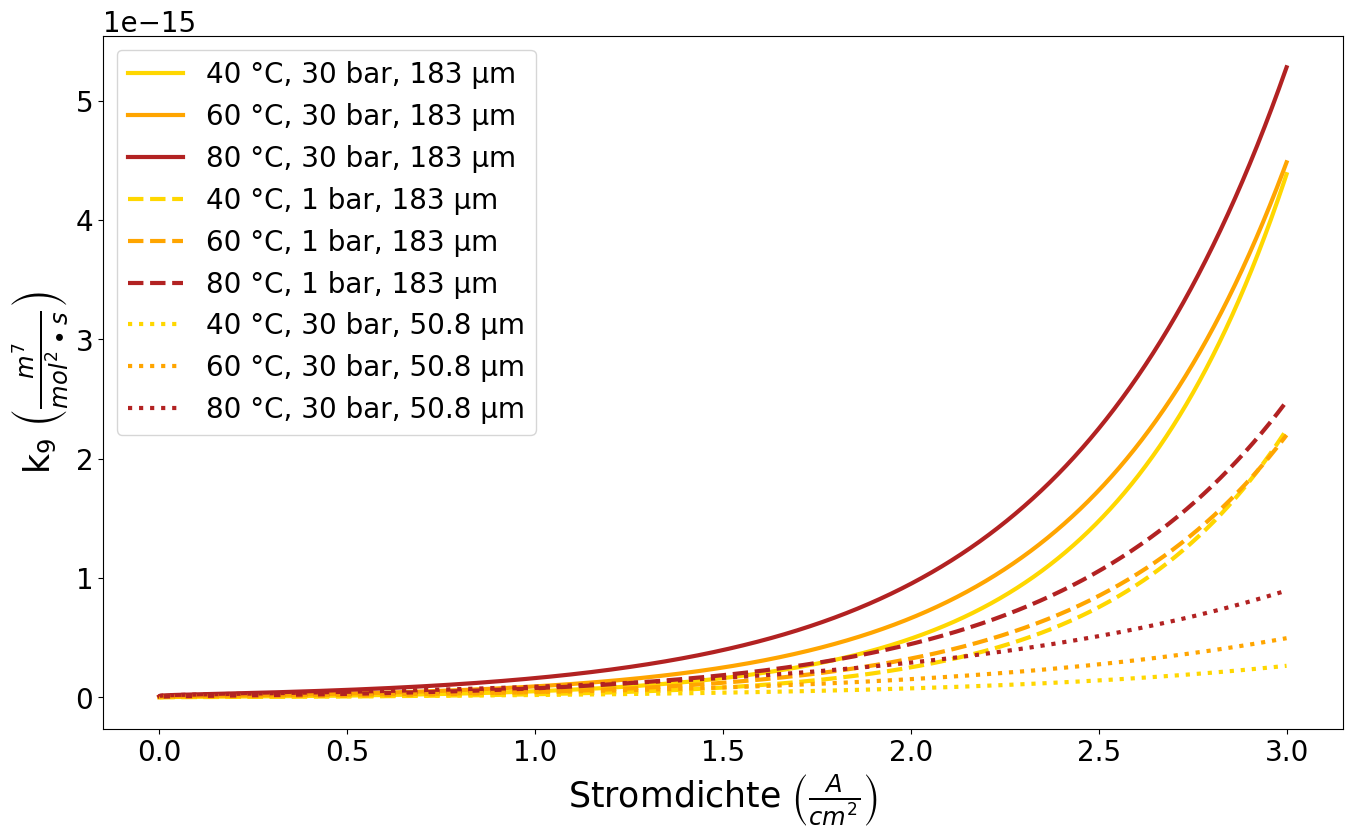

[-0.00561034 -0.00561034 -0.00070146 ...  0.31778574  0.31781189
  0.31783804]
[-0.00128345 -0.00128345  0.00362897 ...  0.35397924  0.35400841
  0.35403757]
[-0.03789727 -0.03789727 -0.03298486 ...  0.3173653   0.31739446
  0.31742363]
[-0.03790864 -0.03790864 -0.03300754 ...  0.20430723  0.20432508
  0.20434294]


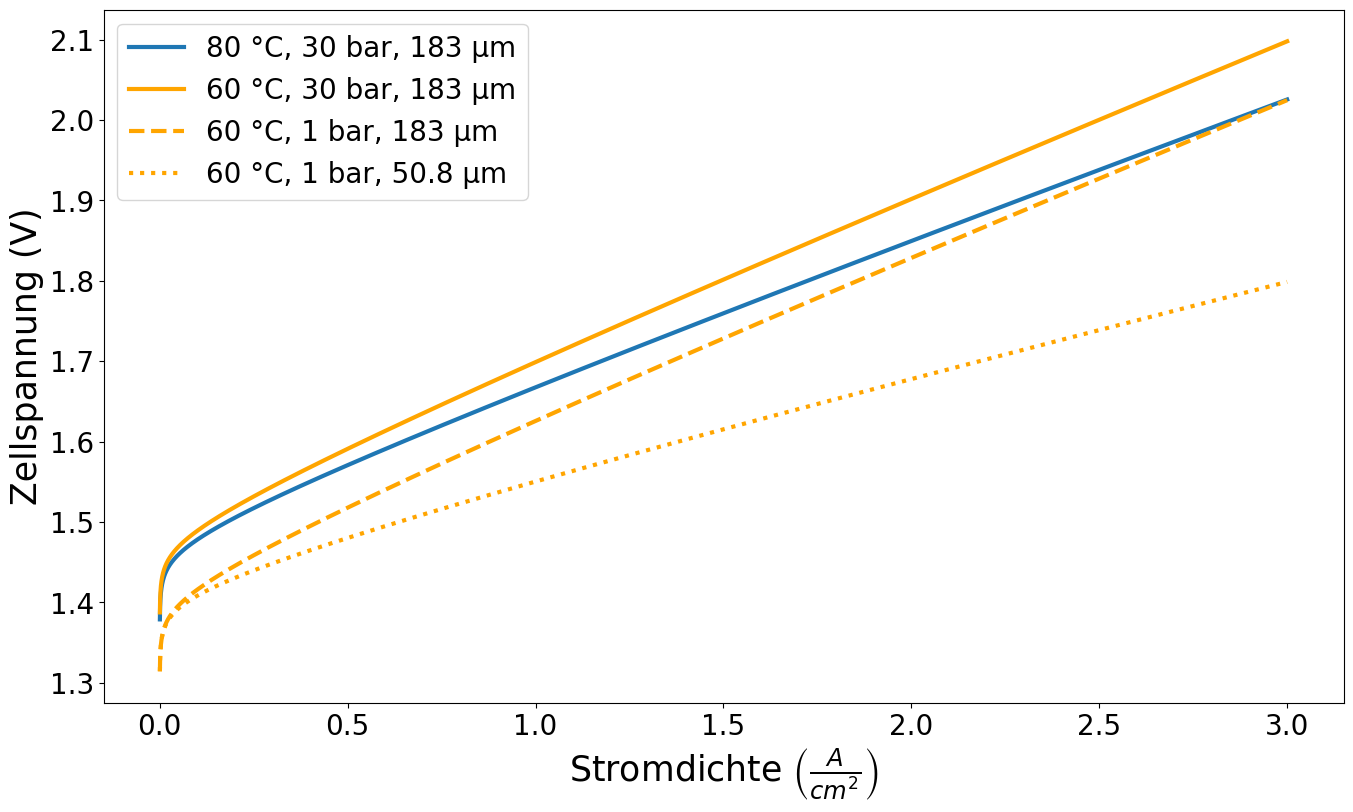

In [4]:
plt.figure(figsize=(16,9))
plt.rc("font", size=20)
plt.plot(j/1e4, rate_const_H2O2(273.15+40,30e5,30e5,183e-6)[0], label="40 °C, 30 bar, 183 µm", linewidth=3, color="gold")
plt.plot(j/1e4, rate_const_H2O2(273.15+60,30e5,30e5,183e-6)[0], label="60 °C, 30 bar, 183 µm", linewidth=3, color="orange")
plt.plot(j/1e4, rate_const_H2O2(273.15+80,30e5,30e5,183e-6)[0], label="80 °C, 30 bar, 183 µm", linewidth=3, color="firebrick")
plt.plot(j/1e4, rate_const_H2O2(273.15+40,1e5,1e5,183e-6)[0], label="40 °C, 1 bar, 183 µm", linewidth=3, color="gold", linestyle="dashed")
plt.plot(j/1e4, rate_const_H2O2(273.15+60,1e5,1e5,183e-6)[0], label="60 °C, 1 bar, 183 µm", linewidth=3, color="orange", linestyle="dashed")
plt.plot(j/1e4, rate_const_H2O2(273.15+80,1e5,1e5,183e-6)[0], label="80 °C, 1 bar, 183 µm", linewidth=3, color="firebrick", linestyle="dashed")
plt.plot(j/1e4, rate_const_H2O2(273.15+40,30e5,30e5,50.8e-6)[0], label="40 °C, 30 bar, 50.8 µm", linewidth=3, color="gold", linestyle="dotted")
plt.plot(j/1e4, rate_const_H2O2(273.15+60,30e5,30e5,50.8e-6)[0], label="60 °C, 30 bar, 50.8 µm", linewidth=3, color="orange", linestyle="dotted")
plt.plot(j/1e4, rate_const_H2O2(273.15+80,30e5,30e5,50.8e-6)[0], label="80 °C, 30 bar, 50.8 µm", linewidth=3, color="firebrick", linestyle="dotted")
plt.legend(fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel(fontsize=25, xlabel=r"Stromdichte $\left(\frac{A}{cm^2}\right)$")
plt.ylabel(fontsize=25, ylabel=r"k$_9$ $\left(\frac{m^7}{mol^2\bullet s}\right)$")
# plt.ylim(0,2e-15)
plt.show()

plt.figure(figsize=(16,9))
plt.plot(j/1e4, rate_const_H2O2(273.15+80,30e5,30e5,183e-6)[2], label="80 °C, 30 bar, 183 µm", linewidth=3)
plt.plot(j/1e4, rate_const_H2O2(273.15+60,30e5,30e5,183e-6)[2], label="60 °C, 30 bar, 183 µm", linewidth=3, color="orange")
plt.plot(j/1e4, rate_const_H2O2(273.15+60,1e5,1e5,183e-6)[2], label="60 °C, 1 bar, 183 µm", linewidth=3, color="orange", linestyle="dashed")
plt.plot(j/1e4, rate_const_H2O2(273.15+60,1e5,1e5,50.8e-6)[2], label="60 °C, 1 bar, 50.8 µm", linewidth=3, color="orange", linestyle="dotted")
plt.legend(fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel(fontsize=25, xlabel=r"Stromdichte $\left(\frac{A}{cm^2}\right)$")
plt.ylabel(fontsize=25, ylabel="Zellspannung (V)")
plt.show()